In [142]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pmdarima as pm
from sklearn.metrics import mean_absolute_error
from utils import meanMAE
from pmdarima.arima import ndiffs
import yfinance as yf
import statsmodels.api as sm


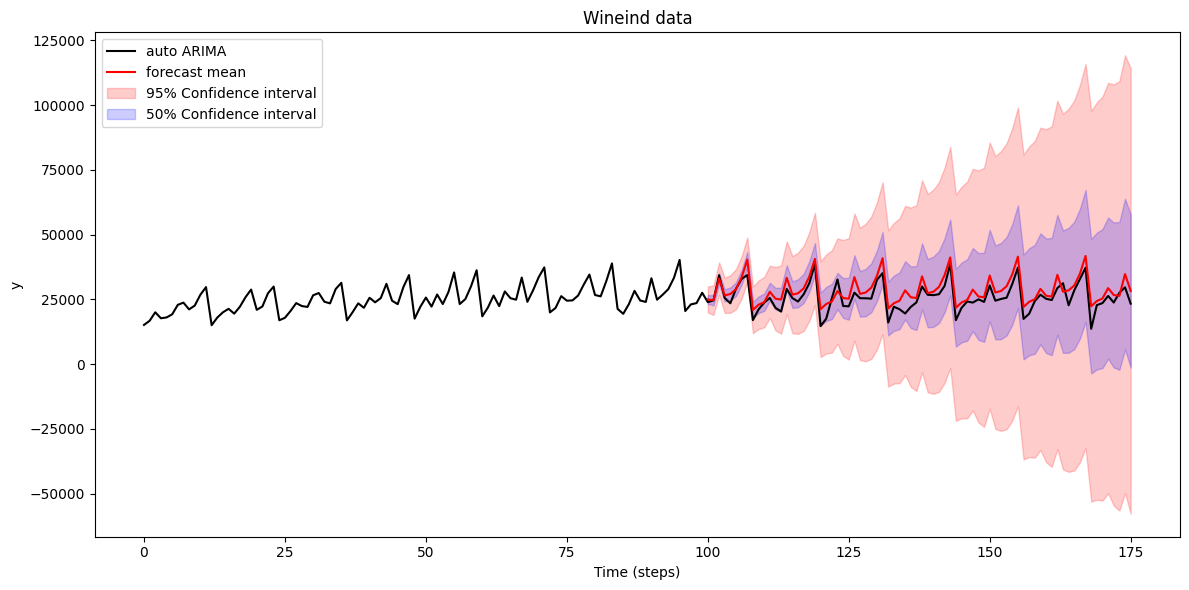

In [145]:
np.random.seed(0)

#data = pm.datasets.load_lynx()
data = pm.datasets.load_wineind()
data=pd.Series(data)

split = 100
model = pm.auto_arima(data.iloc[:split],seasonal=True, suppress_warnings=True,m=12)
result = model.arima_res_

steps = len(data) - split
test = data.iloc[split:]

forecast_res = result.get_forecast(steps=steps)
ci = forecast_res.conf_int(alpha=0.05)
ci.index = test.index

n_sim = 0
sims = []
for _ in range(n_sim):
    sim = result.simulate(nsimulations=steps)
    sim.index = test.index
    sims.append(sim)

plt.figure(figsize=(12, 6))
plt.plot(data.index, data, color="black", label="auto ARIMA")
plt.plot(test.index,forecast_res.predicted_mean,color="red",label="forecast mean")

#for sim in sims:
#    plt.plot(sim.index,sim,color="orange",alpha=0.5,label="Simulations" if n_sim == 1 else None)

plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1],color="red",alpha=0.2,label="95% Confidence interval")

ci50 = forecast_res.conf_int(alpha=0.5)
ci50.index = test.index

plt.fill_between(ci50.index, ci50.iloc[:, 0], ci50.iloc[:, 1],color="blue",alpha=0.2,label="50% Confidence interval")
plt.xlabel("Time (steps)")
plt.ylabel("y")
plt.title('Wineind data')
#plt.title(f'MAE: {mean_absolute_error(data.iloc[split:], forecast_res.predicted_mean):.4f}\n mean MAE: {meanMAE(data.iloc[split:], sims):.4f}\n')
# {mean_absolute_error(data.iloc[split:], sims[0]):.4f}')

plt.legend()
plt.tight_layout()
plt.show()

In [144]:
'''np.random.seed(0)

data = sm.datasets.sunspots.load_pandas().data['SUNACTIVITY']
data = pd.Series(data.values, index=range(len(data)))

split = 260
model = pm.auto_arima(data.iloc[:split],seasonal=True, suppress_warnings=True)
result = model.arima_res_

steps = len(data) - split
test = data.iloc[split:]

forecast_res = result.get_forecast(steps=steps)
ci = forecast_res.conf_int(alpha=0.05)
ci.index = test.index

n_sim = 0
sims = []
for _ in range(n_sim):
    sim = result.simulate(nsimulations=steps)
    sim.index = test.index
    sims.append(sim)

plt.figure(figsize=(12, 6))
plt.plot(data.index, data, color="black", label="auto ARIMA")
plt.plot(test.index,forecast_res.predicted_mean,color="red",label="forecast mean")

#for sim in sims:
#    plt.plot(sim.index,sim,color="orange",alpha=0.5,label="Simulations" if n_sim == 1 else None)

plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1],color="red",alpha=0.2,label="95% Confidence interval")

ci50 = forecast_res.conf_int(alpha=0.5)
ci50.index = test.index

plt.fill_between(ci50.index, ci50.iloc[:, 0], ci50.iloc[:, 1],color="blue",alpha=0.2,label="50% Confidence interval")
plt.xlabel("Time (steps)")
plt.ylabel("y")

#plt.title(f'MAE: {mean_absolute_error(data.iloc[split:], forecast_res.predicted_mean):.4f}\n mean MAE: {meanMAE(data.iloc[split:], sims):.4f}\n')
# {mean_absolute_error(data.iloc[split:], sims[0]):.4f}')

plt.legend()
plt.tight_layout()
plt.show()
'''

'np.random.seed(0)\n\ndata = sm.datasets.sunspots.load_pandas().data[\'SUNACTIVITY\']\ndata = pd.Series(data.values, index=range(len(data)))\n\nsplit = 260\nmodel = pm.auto_arima(data.iloc[:split],seasonal=True, suppress_warnings=True)\nresult = model.arima_res_\n\nsteps = len(data) - split\ntest = data.iloc[split:]\n\nforecast_res = result.get_forecast(steps=steps)\nci = forecast_res.conf_int(alpha=0.05)\nci.index = test.index\n\nn_sim = 0\nsims = []\nfor _ in range(n_sim):\n    sim = result.simulate(nsimulations=steps)\n    sim.index = test.index\n    sims.append(sim)\n\nplt.figure(figsize=(12, 6))\nplt.plot(data.index, data, color="black", label="auto ARIMA")\nplt.plot(test.index,forecast_res.predicted_mean,color="red",label="forecast mean")\n\n#for sim in sims:\n#    plt.plot(sim.index,sim,color="orange",alpha=0.5,label="Simulations" if n_sim == 1 else None)\n\nplt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1],color="red",alpha=0.2,label="95% Confidence interval")\n\nci50 = f